# **7주차: Computer Vision**

In [ ]:
!pip install torch
!pip install torchvision

## **이미지 데이터**

이미지는 0~255의 값을 가지는 픽셀(Pixel) 단위로 이루어져 있으며,

흑백 이미지는 1개의 채널, 컬러 이미지는 RGB 3개의 채널로 구성되어 있음 </br> </br>

<img src="https://www.insilicogen.com/blog/attach/1/1167793122.png" width=300> </br> </br>

$C$는 채널의 수, $H$는 높이, $W$는 너비라고 생각하면, 

이미지 데이터의 형태는 $(C, H, W)$로 표현 가능함

### **이미지의 특성**

#### **정상성 (Stationarity)**

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fdoi94l%2FbtqWUp41yuN%2F2Ldgg3I4JkzUeQuPU8Qhy1%2Fimg.png" width=500> </br> </br>

이미지에서 특정 패턴은 위치에 상관없이 반복적으로 나타나며, 동일한 특성을 지님

#### **지역성 (Locallity)** 

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2F6u5K1%2FbtqWUqbLzfd%2FjKifXv7NG9CwZoDZ8sLmlK%2Fimg.png" width=250> </br> </br>

이미지에서 지니고 있는 특징이나 패턴은 이미지 전체가 아니라 일부 지역에 근접한 픽셀들로 구성되어 있음

### **이미지 데이터에 MLP를 이용한다면?**

각 픽셀을 하나의 특성으로 생각하여 $(C, H, W)$ 형태의 이미지 데이터를 $(CHW)$ 형태로 변형시킨다면,

MLP에 이미지 데이터를 입력값으로 넣어 활용할 수 있음 </br> </br>

<img src="https://i.ibb.co/FsPRnN3/2024-11-13-3-06-02.png" width=300> </br> </br>

하지만, 이미지 데이터에 MLP를 이용하는 것은 그렇게 좋은 선택은 아님 </br> </br>

이미지는 수많은 픽셀로 이루어져 있고, 이미지 크기가 커질수록 입력 데이터의 차원이 매우 커지는데,

이에 따라 가중치의 수가 기하급수적으로 증가하기 때문에 메모리와 연산 비용적인 면에서 비효율적이고, 과적합이 발생할 확률이 높아짐 </br> </br>

또한, 이미지 데이터는 다른 데이터와는 다르게 공간적인 구조를 가지고 있고 그 공간 내에서 정상성과 지역성을 지니고 있는데,

MLP는 모든 픽셀 간의 관계를 학습하기 때문에 이러한 특성들을 고려하기 어려운 구조적인 한계가 존재함 </br> </br>

따라서, 이미지의 특성에 맞는 모델을 활용하는 것이 좋은 선택임

**이미지 데이터 예시**

In [ ]:
import torchvision

to_tensor = torchvision.transforms.ToTensor()                   # transform to tensor and normalize 0~1
dataset = torchvision.datasets.CIFAR10(root="./",               # dataset root
                                       train=True,              # train/test dataset
                                       download=True,           # download dataset
                                       transform=to_tensor)     # torchvison transformation

print(f"image data shape: {dataset[0][0].size()}")

## **합성곱 신경망 (Convolutional Neural Network, CNN)**

<img src="https://blog.kakaocdn.net/dn/diCPnf/btsz9Zd2eSv/C8861aIKZpKod8qaQkYmaK/img.png" width=500> </br> </br>

이미지나 시계열 데이터와 같은 그리드(Grid) 형태의 공간적/시간적 구조가 있는 데이터를 처리하는 데 특화된 신경망 구조로,

합성곱 층 (Convolutional Layer), 비선형 활성화함수 (Non-linear Activation Function), 풀링 층 (Pooling Layer), 완전 연결계층 (Fully-connected Layer)으로 구성되어 있음

### **합성곱 층 (Convolutional Layer)**

<img src="https://www.insilicogen.com/blog/attach/1/1379830475.png" width=400> </br> </br>

입력 데이터와 필터(Filter) 사이의 합성곱 연산을 수행하는 층으로,

주어진 입력 데이터에서 특징맵(Feature Map)을 추출하는 역할을 담당함

#### **필터 (Filter)**

필터는 커널(Kernel)이라고도 부르며, 입력 데이터의 특정 패턴을 탐지할 수 있도록 학습되는 가중치를 말함

필터는 입력 데이터 위를 슬라이딩 하면서 이동하는데, 각 위치에서 필터에 대응하는 요소끼리 곱한 뒤 합산하는 합성곱 연산을 반복하여 하나의 특징맵을 생성함 

또한, 각 필터에는 하나씩의 편향이 있기 때문에 합성곱 연산으로 나온 특징맵에 편향을 더해주는 과정이 있음</br> </br>

<img src="https://velog.velcdn.com/images/2a_02/post/66add7ca-a033-4c4a-928e-dd2d55cbac2d/image.png" width=400> </br> </br>

필터의 채널 수는 입력 데이터의 채널 수와 같아야 하는데, 

입력 데이터의 형태가 $(C_{in}, H, W)$이면 필터의 형태는 $(C_{in}, H_{f}, W_{f})$라고 볼 수 있으며,

이러한 필터가 $C_{out}$개 쌓이게 되면 최종적으로 합성곱 층 가중치의 형태는 $(C_{out}, C_{in}, H_{f}, W_{f})$를 이룬다고 볼 수 있음

#### **패딩 (Padding) 및 스트라이드 (Stride)**

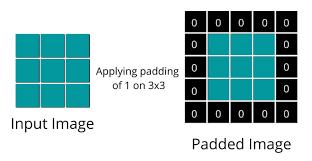 </br> </br>

패딩은 합성곱 연산을 수행하기 전에 입력 데이터 가장자리 부분에 여분의 픽셀을 추가하는 과정으로,

입력 데이터의 가장자리 부분애서 합성곱 연산 횟수를 늘려 가장자리 부분의 정보를 잘 보존시킬 수 있고, 데이터의 크기가 너무 작아지지 않게 출력 크기를 조정할 수 있음

입력 데이터의 가장자리 주변을 0으로 채우는 방법인 제로 패딩 (Zero Padding)이 가장 일반적인 패딩 방식임 </br> </br>

<img src="https://svitla.com/uploads/ckeditor/2024/Math%20at%20the%20heart%20of%20CNN/Convolution%20with%20stride.png" width=400>

스트라이드는 합성곱 연산을 수행할 때 필터가 입력 데이터 위에서 이동하는 간격으로,

스트라이드를 늘리면 합성곱 연산을 이용할 때, 더 빠르고 효율적으로 작은 특징맵을 만들 수 있음 </br> </br>

패딩과 스트라이드를 적용한 합성곱 연산을 진행했을 때, 출력 크기는 다음과 같다고 볼 수 있음

$H_{out} = \dfrac{H_{in} - H_{f} + 2P}{S} + 1 \;\;\;\;\;\;\;\; W_{out} = \dfrac{W_{in} - W_{f} + 2P}{S} + 1$

<span style="font-size: 13px">

 $(H_{in}, W_{in})$ : 입력 크기 &#160;&#160;  $(H_{f}, W_{f})$ : 필터 크기 &#160;&#160; $P$ : 패딩 &#160;&#160; $S$ : 스트라이드 &#160;&#160; $(H_{out}, W_{out})$ : 출력 크기

</span>

#### **합성곱 층의 특징**

필터는 입력 데이터 위에서 슬라이딩으로 이동하면서 합성곱 연산을 수행하기 때문에, 

파라미터가 입력 데이터의 모든 위치에서 공유하는 특성 (Parameter Sharing)을 가지고 있음 </br> </br>

<img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FbIqaMi%2FbtrvwjChTPv%2FgTPrKkmkInHBU61TjTOjB1%2Fimg.png" width=300> </br> </br>

이로 인해 입력 데이터 안에 존재하는 특정 패턴을 위치에 상관없이 동일하게 인식할 수 있으며 (Translation Equivariance),

적은 수의 파라미터를 가져 이미지 전역에서 일반화된 특징을 효율적으로 학습할 수 있고 과적합 위험성을 줄여줌 </br> </br>

<img src="https://velog.velcdn.com/images/ktm1237/post/72d8f187-5a3f-4f03-a92a-636e88a76b4b/image.png" width=500> </br> </br>

또한, 필터는 이미지 전체가 아니라 이미지의 일부 영역과 대응되어 계산되기 때문에 (Locality) 국소적인 패턴을 잘 학습하며,

합성곱 층이 여러 층 쌓이게 되면 작은 국소적 특징들이 쌓여서 더 복잡한 전역적 특징으로 확장될 수 있음 </br> </br>

이러한 특성들 덕분에 합성곱 층은 이미지 데이터에서 잘 작동하며,

강한 귀납적 편향 (Inductive Bias)을 가져 적은 데이터와 비교적 작은 모델 규모로도 높은 성능을 발휘할 수 있음 </br> </br>

*귀납적 편향 (Inductive Bias)

모델 학습 시에는 만나보지 않았던 상황에 대하여 정확한 예측을 하기 위해 사용하는 추가적인 가정으로,

모델이 새롭게 들어오는 데이터에 대하여 가지고 있는 가정이라고 볼 수 있음

**합성곱 층 예시**

In [ ]:
import torch
import torch.nn as nn

h_in, w_in = 32, 32
c_in, c_out = 10, 20
pad, stride = 1, 1
kernel_size = (5,5)

data = torch.randn(1, c_in, h_in, w_in)

conv = nn.Conv2d(in_channels=c_in,              # number of channels in input data
                 out_channels=c_out,            # number of channels in output data
                 kernel_size=kernel_size,       # filter size
                 stride=stride,                 # stride of convolution
                 padding=pad)                   # padding added to all four sides of the input data
output = conv(data)

print(f"the shape of data before convoluton: {data.size()[1:]}")
print(f"the shape of data after convoluton: {output.size()[1:]}")

### **풀링 층 (Pooling Layer)**

학습 가능한 파라미터 없이 특징맵의 공간적 차원을 줄이는 층으로,

지정된 크기의 필터가 입력 데이터 위를 일정 간격(스트라이드)으로 이동하며 각 영역에서 특정 연산을 수행하여 특징맵을 생성함 </br> </br>

풀링은 각 채널별로 독립적으로 적용되는 연산으로 채널 간에는 서로 영향을 주지 않으며,

대표적으로 맥스 풀링 (Max Pooling), 평균 풀링 (Average Pooling) 등이 있음

#### **맥스 풀링 (Max Pooling)**

<img src="https://cs231n.github.io/assets/cnn/maxpool.jpeg" width=400>

주어진 영역에서 가장 큰 값을 선택하는 풀링 방식으로,

주요 특징을 강조하고 노이즈를 제거하는 데 효과적으로 가장 중요한 특징을 보존할 수 있음

일반적으로 가장 많이 사용되는 풀링 방식임

**맥스 풀링 예시**

In [ ]:
import torch
import torch.nn as nn

stride = 2
kernel_size = (2,2)

data = torch.arange(16, dtype=torch.float32).view(1,1,4,4)      # reshape to (1,1,4,4)

max_pool = nn.MaxPool2d(kernel_size=kernel_size,                # filter size
                        stride=stride)                          # stride of window
output = max_pool(data)

print(f"data before max pooling\n{data}\n")
print(f"data after max pooling\n{output}")

#### **평균 풀링 (Average Pooling)**

<img src="https://www.researchgate.net/profile/Juan_Pedro_Dominguez-Morales/publication/329885401/figure/fig21/AS:707709083062277@1545742402308/Average-pooling-example.png" width=400>

주어진 영역에서 평균값을 구하는 풀링 방식으로,

특징을 부드럽게 요약하여 안정적인 특징을 유지할 수 있으며, 잡음이 적은 데이터에서 유용할 수 있음

**평균 풀링 예시**

In [ ]:
import torch
import torch.nn as nn

stride = 2
kernel_size = (2,2)

data = torch.arange(16, dtype=torch.float32).view(1,1,4,4)      # reshape to (1,1,4,4)

max_pool = nn.AvgPool2d(kernel_size=kernel_size,                # filter size
                        stride=stride)                          # stride of window
output = max_pool(data)

print(f"data before average pooling\n{data}\n")
print(f"data after average pooling\n{output}")

#### **풀링 층의 특징**

학습 가능한 파라미터 없이 특징맵의 공간적 차원을 줄여주기 때문에 연산량과 메모리 사용량이 감소하게 되어 효율적이며, 

주어진 영역 내에서 작은 변화를 무시하고 중요한 정보를 요약하기 때문에 과적합을 방지하는데 유리함 </br> </br>

<img src="https://blog.kakaocdn.net/dn/bbxQM4/btsFsmXOKBC/yBl336uZMfQF540Hc9qB20/img.png" width=400> </br> </br>

또한, 풀링이 일어나는 영역 내에서는 입력값의 순서가 바뀌어도 출력값은 바뀌지 않는 변환 불변성(Translation Invariance)을 가지고 있는데,

이는 입력 데이터의 특정 패턴이 어떤 위치에 있든 상관없이 탐지할 수 있도록 만드는 역할을 함 </br> </br>

하지만, 학습 가능한 파라미터가 없이 특징맵이 축소되다 보니 풀링 과정에서 세부 정보가 손실될 수 있다는 단점이 존재함

### **완전 연결계층 (Fully-connected Layer)**

합성곱 층과 풀링 층을 거치며 생성된 특징맵은 이미지의 공간적 특징을 잘 표현하지만 이를 특정 클래스나 값을 예측하는 데 적합하지는 않음

따라서, 특징맵을 1차원으로 벡터 형태로 펼친 후, 모든 특징을 완전 연결계층으로 연결하여 최종적으로 분류나 회귀 태스크를 수행할 수 있음



## **CNN의 역사**

CNN은 1989년 “Backpropagation applied to handwritten zip code recognition, LeCun" 에서 처음 소개되었고,

1998년 "Gradient-based learning applied to document recognition, LeCun"의 LeNet이 나오면서 CNN의 본격적인 구조가 탄생하게 됨

이후 AlexNet, VGG, GoogleNet, ResNet의 흐름으로 CNN 모델이 발전하게 됨

### **AlexNet**

<img src="https://miro.medium.com/proxy/1*qyc21qM0oxWEuRaj-XJKcw.png" width=600> </br> </br>

AlexNet은 ImageNet 데이터 분류 성능을 측정하는 ILSVRC 대회에서 2012년 당시 2위랑 큰 차이를 보이며 우승하여 CNN 모델에 대한 관심을 높이고 가능성을 증명한 모델

ReLU 비선형 활성화 함수를 처음으로 사용하였고, 드롭아웃, 데이터 증강, Local Response Normalization (LRN) 등을 활용하여 성능을 높였음 

**AlexNet 예시**

In [ ]:
import torchvision

alexnet = torchvision.models.alexnet(pretrained=False)

print(alexnet)

### **VGG**

<img src="https://miro.medium.com/v2/resize:fit:1400/1*YpXrr8bN5XyqOlztKPHvDw@2x.png" width=400> </br> </br>

이전 CNN 모델과는 다르게 작은 필터 (3x3)를 깊게 쌓는 단순한 접근 방식을 활용하여 성능을 높인 모델

#### **수용 영역 (Receptive Field)**

특정 활성화 값에 영향을 주는 입력 데이터 값의 범위나 영역을 의미하며,

합성곱 층이나 풀링 층이 점점 쌓이게 되면, 특정 활성화 값에 영향을 주는 입력 데이터의 범위나 영역이 점점 누적되어 늘어난다고 볼 수 있음

#### **크기가 작은 필터를 여러 번 깊게**

수용 영역 (Receptive Field) 측면에서 큰 필터와 작은 필터를 비교해보았을 때,

하나의 값에 25의 수용 영역을 가지도록 만드려면, 큰 필터 (5x5)를 한 번 적용하는 방안이랑 작은 필터 (3x3)을 두 번 적용하는 방안이 있음 </br> </br>

큰 필터를 한 번 적용하는 것은 5x5개의 가중치를 가지고 비선형 변환을 한 번 거치는 것으로 볼 수 있는 반면,

작은 필터를 두번 적용하는 것은 3x3+3x3개의 가중치를 가지고 비선형 변환을 두 번 거치는 것이라고 볼 수 있음 </br> </br>

따라서, 큰 필터를 한 번 적용하는 것보다 작은 필터를 여러 번 적용하는 것이 파라미터 수를 줄이고,

모델이 더 많은 비선형성과 복잡한 패턴을 학습할 수 있게 만들어준다는 장점이 있음 </br> </br>

하지만, 모델이 깊어지면서 학습이 어려워지고 학습 시간이 오래 걸릴 수도 있으며,

작은 필터로 특징맵의 크기가 덜 축소되다 보니 완전 연결계층에서 매우 많은 파라미터 수를 가지게 되어 메모리 사용량이 커진다는 단점이 존재함

**VGG 예시**

In [ ]:
import torchvision

vgg16 = torchvision.models.vgg16(pretrained=False)

print(vgg16)

### **GoogLeNet**

<img src="https://miro.medium.com/v2/resize:fit:1200/0*q5eMDjUHKqEyo7qY.png" width=550>

네트워크를 깊게 유지하여 성능을 올리면서도 파라미터 수를 줄여 효율성을 높인 아키텍처를 제안한 모델

성능과 효율성을 위해 인셉션 모듈 (Inception Module), 전역 평균 풀링 (Global Average Pooling), 보조 분류기 (Auxiliary Classifier)를 활용함

#### **인셉션 모듈 (Inception Module)** 

<img src="https://production-media.paperswithcode.com/methods/Screen_Shot_2020-06-22_at_3.22.39_PM.png" width=500> </br> </br>

네트워크 안의 네트워크 (Network in Network)라고 불리며, 

서로 다른 크기의 필터를 적용하여 하나의 입력 데이터에 대하여 다양한 특징을 추출하고 합치는 과정을 진행함 </br> </br>

하지만, 이 과정에서 많은 파라미터와 연산량을 요구하는데,

먼저 1x1 필터를 활용하여 입력 데이터의 채널수를 줄이고, 그 후 서로 다른 크기의 필터를 적용하는 방식을 활용하여 파라미터 수와 연산량을 대폭 줄였음

#### **전역 평균 풀링 (Gloabal Average Pooling)**

<img src="https://magmatart.dev/assets/posts/images/34/figure1.png" width=350> </br> </br>

기존 CNN 모델에서는 마지막 특징맵을 1차원 벡터로 펼쳐서 완전 연결계층을 연결하는 방식을 활용했는데,

펼쳐진 1차원 벡터의 경우 차원수가 크기 때문에 완전 연결계층 부분에서 상당히 많은 파라미터를 가져야 했음 </br> </br>

이에 따라 마지막 특징맵을 1차원 벡터로 펼치는 대신 각 채널의 평균값을 구하는 방식으로 변경함으로써

효율적으로 파라미터 수를 줄여 모델의 복잡도를 낮추어 과적합을 방지하고, 이미지의 전역 정보를 더 잘 반영하게 만듦

#### **보조 분류기 (Auxiliary Classifier)**

<img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FBsnx4%2FbtqDZYLoRLk%2FLvOTpvHKKFUj4ookVPujxK%2Fimg.png" width=600> </br> </br>

모델의 학습 과정에서 보조 분류기를 활용하여 중간 층에서 보조적으로 예측을 수행하고, 이를 손실함수에 포함함으로써

학습 과정에서 기울기 소실 문제를 완화하고 학습 안정성을 높이도록 만듦

**GoogLeNet 예시**

In [ ]:
import torchvision

googlenet = torchvision.models.googlenet(pretrained=False)

print(googlenet)

### **ResNet**

<img src="https://cdn.prod.website-files.com/645cec60ffb18d5ebb37da4b/65eb303c9ee4b67135628e9a_archi.jpg" width=500> </br> </br>

잔차 연결 (Residual Connection)을 통해 기울기 소실 문제를 완화하여 

매우 깊은 네트워크에 대해서도 원활한 학습이 이루어질 수 있도록 만들어준 모델

#### **Degradation 문제**

<img src="https://velog.velcdn.com/images/osk3441/post/279d57a2-ae32-4c65-9b7d-fc0fe3a127e5/image.png" width=350> </br> </br>

기존 CNN 모델에서 층이 깊어졌을 때 모델이 수렴했음에도 불구하고 오히려 층의 개수가 적을 때보다 학습/테스트 오차 모두 더 커지는 현상이 발생함 

이는 과적합 때문이 아니라 네트워크 구조상 층을 깊이 쌓았을 때 최적화가 잘 안되기 때문에 발생하는 문제라고 보고, 이를 Degradataion 문제라고 명명함

#### **잔차 연결 (Residual Connection)**

잘 최적화된 모델은 현재 층에서 새로운 특징을 추출하면서도 이전 층에서 추출한 특징을 잘 보존해야 함

하지만, 일반적으로 이전 층에서 추출한 특징을 보존하면서 현재 층에서 새로운 특징까지 추출하여 더하는 것은 굉장히 어려운 일이기 때문에

층이 깊어질수록 입력값 그대로를 출력하는 Identity Mapping이 힘들어지고 기울기 소실 문제도 발생하여, 결국 모델의 최적화가 힘들어지게 됨 </br> </br>

<img src="https://annajeong.github.io/assets/images/dataScience/resnet-1" width=350> </br> </br>

잔차 연결은 층을 지난 출력값에 입력값을 그대로 Identity Mapping하여 더해주는 기술로, 

층에 입력값이 들어가게 되면 그 출력값에 최소한의 Identity Mapping을 보장해주는 특징을 가지고 있음 </br> </br>

이후에 모델을 역전파 시켜 학습을 진행할 때에도 Identity Mapping을 따라 그래디언트가 흐르기 때문에 기울기 소실 문제를 완화해주고,

잔차 연결이 적용된 층은 이전 층에서 추출한 특징을 보존할 필요 없이 단순히 새로운 특징만을 학습하면 되기 때문에 모델의 학습이 더 쉬워짐 </br> </br>

모델을 학습할 때, 추출해야 될 전체 특징 중에서 이전 층에서 추출한 특징들을 제외한 나머지 특징(잔차)을 학습하면 되기 때문에

이를 잔차 학습 (Residual Learning)이라고 부름


**ResNet 예시**

In [ ]:
import torchvision

resnet18 = torchvision.models.resnet18(pretrained=False)

print(resnet18)

## **전이 학습 (Transfer Learning)**

전이 학습은 어떤 데이터셋과 태스크로 사전 학습된 모델의 지식을 다른 데이터셋과 태스크에 적용하는 것으로,

학습시키려는 모델을 사전 학습된 모델의 가중치로 초기화한 후, 업데이트를 진행할 층을 선택하여 추가적으로 학습시키는 것을 의미함 </br> </br>

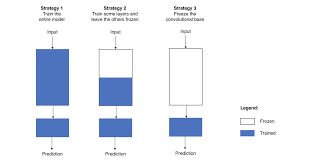 </br> </br>

전이 학습을 사용하면 모델이 사전 학습된 지식을 바탕으로 빠르게 수렴할 수 있고,

대규모 데이터셋에서 학습된 고차원적이고 추상적인 특징을 이용하므로 작은 데이터셋으로도 좋은 성능을 보일 수 있음 </br> </br>

하지만, 사전 학습된 모델이 현재 학습시키려는 모델에 적합한지를 먼저 판단해야 하는데,

사전 학습된 데이터셋과 태스크, 현재 학습시키려는 데이터셋과 태스크를 비교해보았을 때,

차이가 나는 만큼 추가적으로 학습시킬 층을 설정하고, 차이가 엄청 많이 나면 차라리 모델을 새롭게 학습시키는 것이 좋은 선택임

**전이 학습 예시**

In [ ]:
import torchvision

# load pretrained model
model = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT     # pretrained weights
)

# freeze all parameters except for classifier
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad_(False)

"""
Training Code

"""

print("trainable parameters list")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

## **다양한 컴퓨터비전 태스크**

### **이미지 분류 (Image Classification)**

<img src="https://velog.velcdn.com/images/hipjaengyi_cat18/post/dcb3bbb6-0352-420d-bca4-7cf552048368/image.png" width=400> </br> </br>

주어진 이미지가 어떤 카테고리(클래스)에 속하는지 분류하는 태스크

### **객체 검출 (Object Detection)**

<img src="https://blog.kakaocdn.net/dn/VeHmE/btsJHn4Dg4C/b1FS7M6dkYzSMRR9kjK360/img.webp" width=350> </br> </br>

주어진 이미지 내에서 특정 개체의 위치를 찾고, 해당 객체가 어떤 카테고리(클래스)에 속하는지 분류하는 태스크

특정 개체의 위치는 바운딩 박스로 표현하는데, 바운딩 박스는 중심 좌표, 높이, 너비 $(x,y,w,h)$로 이루어져 있고 각각의 값들을 회귀를 통해 구함

### **분할 (Segmentation)**

<img src="https://www.labellerr.com/blog/content/images/2022/12/banner-2-1.webp" width=400> </br> </br>

주어진 이미지에서 픽셀 단위로 어떤 카테고리(클래스)에 속하는지 분류하는 태스크

분할하려는 대상에 따라 Semantic Segmentation, Instance Segmentation, Panoptic Segmention 등이 있음

### **자세 추정(Pose Estimation)**

<img src="https://viso.ai/wp-content/uploads/2021/01/Keypoints-Detected-by-OpenPose-on-the-COCO-Dataset.jpg" width=350> </br> </br>

주어진 이미지에서 사람이나 객체의 특정 중요한 부분들 (예를 들어, 신체 부위나 관절)의 위치를 추정하는 태스크

사람이나 객체의 특정 중요한 부분들은 회귀를 통해 구하는데, 직접적으로 구하는 Keypoint Regression 방법과 확률분포를 이용하여 구하는 Heatmap Regression 방법이 있음

### **이미지 생성 (Image Generation)**

<img src="https://www.researchgate.net/publication/353838206/figure/fig1/AS:1055827360231431@1628740267940/Progress-of-image-generation-made-by-different-GAN-models-over-the-years.jpg" width=800>

주어진 이미지 분포를 학습하여 이미지 분포 내에 있는 새로운 이미지를 생성하는 태스크

현재는 주로 멀티모달을 활용하여 주어진 조건이나 입력을 기반으로 새로운 이미지를 생성함